# Fit nonlinear function to network performance

This script takes in the results from data-overview.ipynb, and performs a regression to extract the impact of different regulatory parameters on the data.

In [1]:
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
from matplotlib.backends.backend_pdf import PdfPages

import matplotlib as mpl
import matplotlib.ticker as ticker

import numpy as np
import pandas as pd
import os
import plotly.graph_objects as go
import plotly.express as px
import pickle
import time

# import clustering packages
from sklearn.linear_model import LinearRegression
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import DotProduct, WhiteKernel
import seaborn as sns
import statsmodels.api as sm
import statsmodels.formula.api as smf
from scipy.optimize import curve_fit
from scipy.interpolate import UnivariateSpline, interp1d
from scipy.signal import savgol_filter

plt.style.use('custom.mplstyle')
%config InlineBackend.figure_format = 'retina'
from tqdm import tqdm
from joblib import Parallel, delayed

from stoch_sim_model import *

In [2]:
# Load data from 2nd infections
reg_model = ''
runs = '-1-'
comment = "acute_all-sparse-reg"
d = '/gscratch/scrubbed/oukogu/infoimmune/sim_output/no_cell_var/summary_stats/mean/fits/'
d_mean = '/gscratch/scrubbed/oukogu/infoimmune/sim_output/no_cell_var/summary_stats/mean/processed_data'+runs+'runs'+'-'+comment+'.pkl'

# Import datasets
clustered_mean_df = pd.read_pickle(d_mean)
with open('/gscratch/scrubbed/oukogu/infoimmune/sim_output/no_cell_var/summary_stats/mean/list_processed_data'+runs+'runs'+'-'+comment+'.pkl', 'rb') as f:
    infection_scenarios = pickle.load(f)

with pd.option_context('display.max_columns', None):
    display(clustered_mean_df)

,psi_myc_I,psi_myc_HI,psi_myc_HE,L0_Na,psi_NE_I,psi_NE_HI,psi_NE_HE,L0_NE,psi_EM_I,psi_EM_HI,psi_EM_HE,L0_EM,psi_Edie_I,psi_Edie_HI,psi_Edie_HE,L0_Edie,d_I,K_I,b_I,K_H,N_0,S_0,I_0,d_S,harm_pI,harm_pS,max_eM_fold,frac_cM,log_T_pEcyteM,T_min_pI,T_max_pI,T_pE_start,T_pE_clear,stim_pI,stim_pHI,stim_pHE,scaled_min_pS,antigenicity_over_harm,harm_pI_noprotection,peff_clearance,peff_toxicity
0,-3.0,-3.0,-3.0,-4.0,0.0,0.0,0.0,-4.0,0.0,0.0,0.0,-4.0,0.0,0.0,0.0,-4.0,0.15,10000.0,1.500000e-07,100000.0,100.0,10000000.0,1000.0,0.01,1.103242e+07,0.000000,0.000000,0.000000,0.000000,0.0,8.68,20.00,11.32,6.52630,1.793448,0.000000,0.015044,3.349148,5.516209,0.000000,0.000000
1,-3.0,-3.0,-3.0,-4.0,0.0,0.0,0.0,-4.0,0.0,0.0,0.0,-4.0,0.0,0.0,0.0,-2.0,0.15,10000.0,1.500000e-07,100000.0,100.0,10000000.0,1000.0,0.01,1.103242e+07,0.000000,0.000000,0.000000,0.000000,0.0,8.68,20.00,11.32,6.52630,1.793448,0.000000,0.015044,3.349148,5.516209,0.000000,0.000000
2,-3.0,-3.0,-3.0,-4.0,0.0,0.0,0.0,-4.0,0.0,0.0,0.0,-4.0,0.0,0.0,0.0,0.0,0.15,10000.0,1.500000e-07,100000.0,100.0,10000000.0,1000.0,0.01,1.103242e+07,0.000000,0.000000,0.000000,0.000000,0.0,8.68,20.00,11.32,6.52630,1.793448,0.000000,0.015044,3.349148,5.516209,0.000000,0.000000
3,-3.0,-3.0,-3.0,-4.0,0.0,0.0,0.0,-4.0,0.0,0.0,0.0,-4.0,0.0,0.0,0.0,2.0,0.15,10000.0,1.500000e-07,100000.0,100.0,10000000.0,1000.0,0.01,1.103242e+07,0.000000,0.000000,0.000000,0.000000,0.0,8.68,20.00,11.32,6.52630,1.793448,0.000000,0.015044,3.349148,5.516209,0.000000,0.000000
4,-3.0,-3.0,-3.0,-4.0,0.0,0.0,0.0,-4.0,0.0,0.0,0.0,-4.0,0.0,0.0,0.0,4.0,0.15,10000.0,1.500000e-07,100000.0,100.0,10000000.0,1000.0,0.01,1.103242e+07,0.000000,0.000000,0.000000,0.000000,0.0,8.68,20.00,11.32,6.52630,1.793448,0.000000,0.015044,3.349148,5.516209,0.000000,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
310620,3.0,3.0,3.0,4.0,0.0,0.0,0.0,4.0,0.0,0.0,0.0,4.0,0.0,0.0,0.0,-4.0,0.01,10000000.0,1.000000e-01,100000.0,1000.0,10000000.0,1000000.0,0.01,2.819433e+06,3012.631374,1.087391,0.154323,0.018548,0.0,0.00,1.91,1.93,0.09531,0.679530,0.009201,0.835335,7.000001,1.412133,0.002417,0.001506
310621,3.0,3.0,3.0,4.0,0.0,0.0,0.0,4.0,0.0,0.0,0.0,4.0,0.0,0.0,0.0,-2.0,0.01,10000000.0,1.000000e-01,100000.0,1000.0,10000000.0,1000000.0,0.01,2.820741e+06,2154.423001,0.963646,0.151440,0.012491,0.0,0.00,20.00,2.00,0.09531,0.679609,0.007890,0.835288,7.000001,1.412133,0.001763,0.001077
310622,3.0,3.0,3.0,4.0,0.0,0.0,0.0,4.0,0.0,0.0,0.0,4.0,0.0,0.0,0.0,0.0,0.01,10000000.0,1.000000e-01,100000.0,1000.0,10000000.0,1000000.0,0.01,2.822269e+06,1217.719480,0.734160,0.141045,0.007411,0.0,0.00,20.00,1.68,0.09531,0.679836,0.004312,0.835227,7.000001,1.412133,0.000999,0.000609
310623,3.0,3.0,3.0,4.0,0.0,0.0,0.0,4.0,0.0,0.0,0.0,4.0,0.0,0.0,0.0,2.0,0.01,10000000.0,1.000000e-01,100000.0,1000.0,10000000.0,1000000.0,0.01,2.822957e+06,791.558770,0.581381,0.142077,0.004882,0.0,0.00,20.00,1.90,0.09531,0.679923,0.003387,0.835200,7.000001,1.412133,0.000655,0.000396


In [3]:
# Define parameters
num_categories = len(perf_vars)
num_modules = len(modules)

module_reg = {'Na': [r for r in Na_reg if np.std(infection_scenarios[10][r].values) > 0], 
              'NE': [r for r in NE_reg if np.std(infection_scenarios[10][r].values) > 0],  
              'EM': [r for r in EM_reg if np.std(infection_scenarios[10][r].values) > 0], 
              'EE': [r for r in EE_reg if np.std(infection_scenarios[10][r].values) > 0]}

module_reg_labels = {'Na': [r for i, r in enumerate(param_names[-16:-12]) if  Na_reg[i] in module_reg['Na']], 
                     'NE': [r for i, r in enumerate(param_names[-12:-8]) if  NE_reg[i] in module_reg['NE']],
                     'EM': [r for i, r in enumerate(param_names[-8:-4]) if  EM_reg[i] in module_reg['EM']],
                     'EE': [r for i, r in enumerate(param_names[-4:]) if  EE_reg[i] in module_reg['EE']]}
reg_label = param_names[-16:]
signal_classes = [r for i, r in enumerate(["Ag.", "Inf. harm", "Resp. harm", "Baselines"]) if np.std(infection_scenarios[0][[Na_reg[i]] + [NE_reg[i]] + [EM_reg[i]] + [EE_reg[i]]].values) > 0]

reg = [r for r in Na_reg + NE_reg + EM_reg + EE_reg if np.std(infection_scenarios[10][r].values) > 0]
key_var = 'antigenicity_over_harm'
n_virs = len(infection_scenarios)
cmap_colors = sns.color_palette('tab20c', 20)

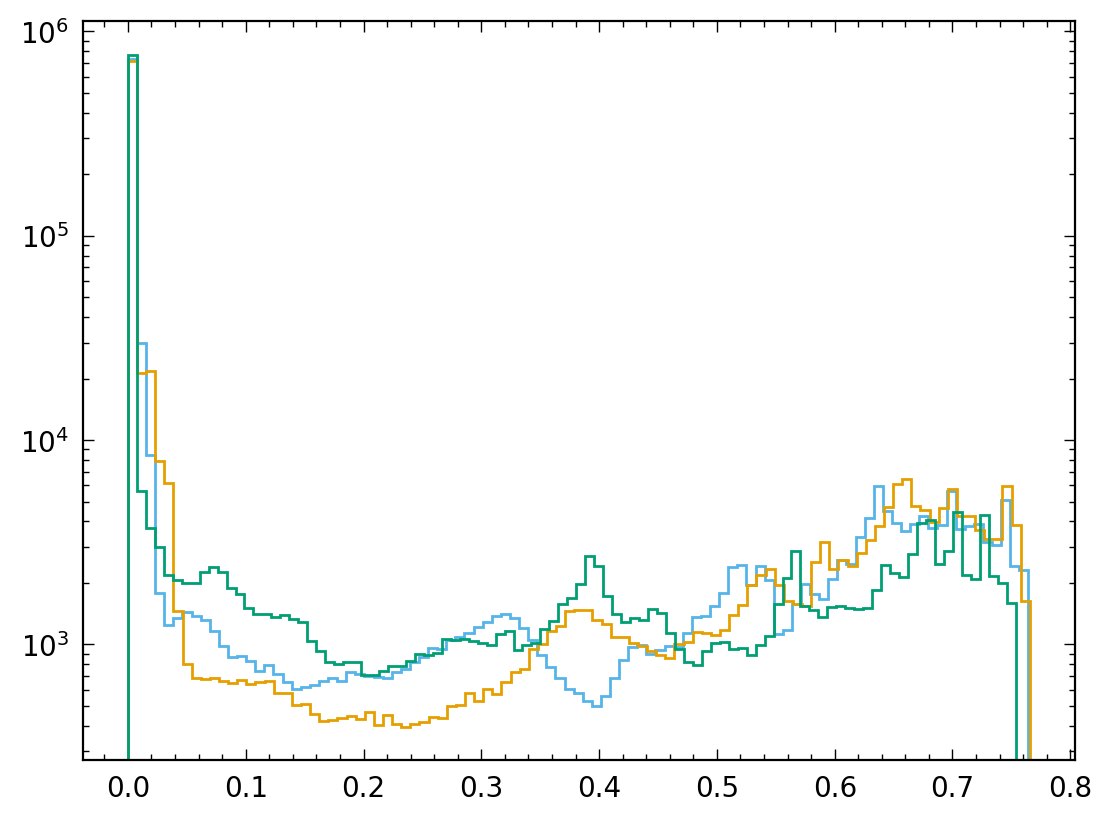

In [4]:
# Inspect distribution of observables
sel = 'peff_clearance'
for a in np.unique(clustered_mean_df.loc[(clustered_mean_df.b_I == b_C)][key_var].values):
    data = clustered_mean_df.loc[clustered_mean_df[key_var] == a]
    plt.hist(data[sel], bins = np.linspace(np.amin(data[sel]), np.amax(data[sel]), 100), histtype = 'step', log = True);

,antigenicity_over_harm,stim_pI,stim_pHI,stim_pHE
0,-1.451789e+17,0.693147,0.680175,3.474681
1,-7.000001e+00,2.397895,0.680175,3.462158
2,5.320459e-01,0.000100,0.007459,2.712606
3,5.492583e-01,0.001308,0.081042,2.706916
4,5.671169e-01,0.012728,0.549200,2.687495
...,...,...,...,...
119,2.725610e+00,5.591479,2.107290,2.691711
120,2.865893e+00,5.916491,2.147300,2.910796
121,3.052721e+00,6.222800,2.077152,3.166618
122,3.349148e+00,6.526300,1.793448,3.411421


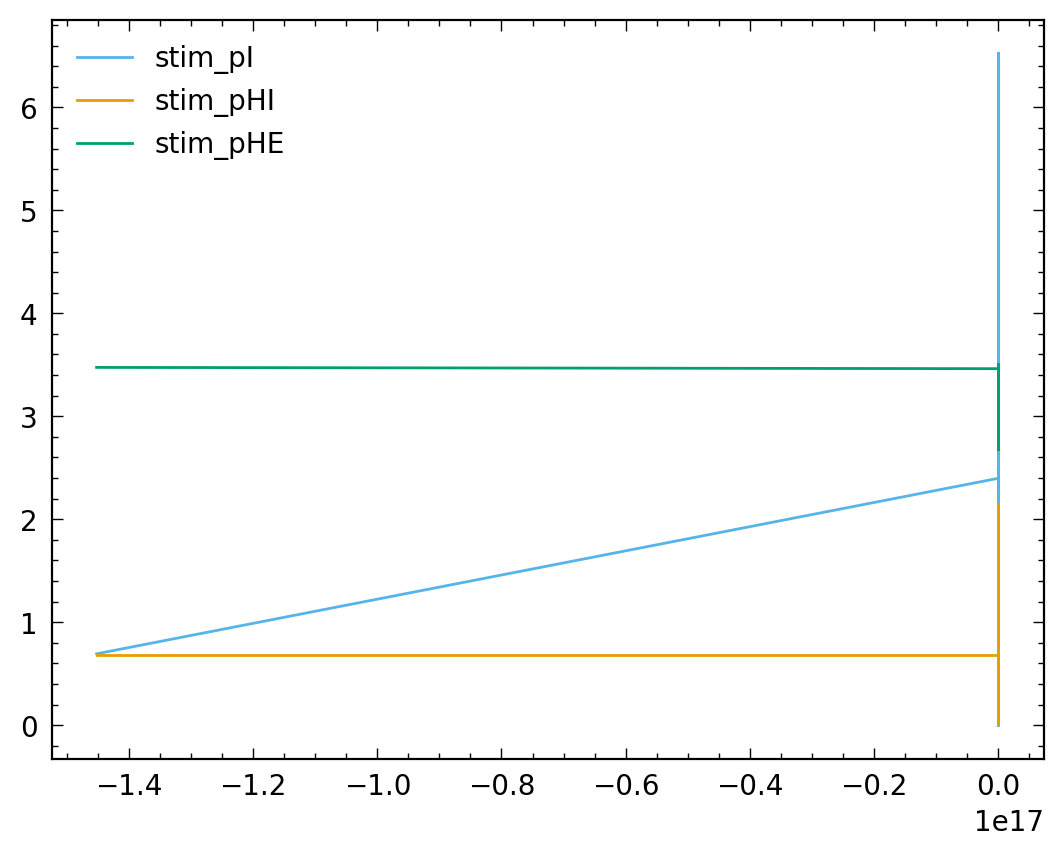

In [5]:
#norm_stim = clustered_mean_df.loc[(np.sum(np.abs(clustered_mean_df[reg_stim]), axis = 1) == 0)].groupby(key_var, as_index = False).mean()[[key_var, 'stim_pI', 'stim_pHI', 'stim_pHE']]
norm_stim = clustered_mean_df.groupby(key_var, as_index = False).max()[[key_var, 'stim_pI', 'stim_pHI', 'stim_pHE']]
with pd.option_context('display.max_columns', None):
    display(norm_stim)
    
plt.plot(norm_stim[key_var], norm_stim[['stim_pI', 'stim_pHI', 'stim_pHE']], label = ['stim_pI', 'stim_pHI', 'stim_pHE'])
plt.legend()

### Fit model to average data
The nonlinear sigmoid model does a good job on the data averaged over infections and marginalized over modules. This is the minimum we require.

fevals: 8
fevals: 27
fevals: 7
fevals: 14
fevals: 58
fevals: 85
fevals: 58
fevals: 10
fevals: 7
fevals: 14
fevals: 8
fevals: 41
fevals: 7
fevals: 14
fevals: 8
fevals: 41


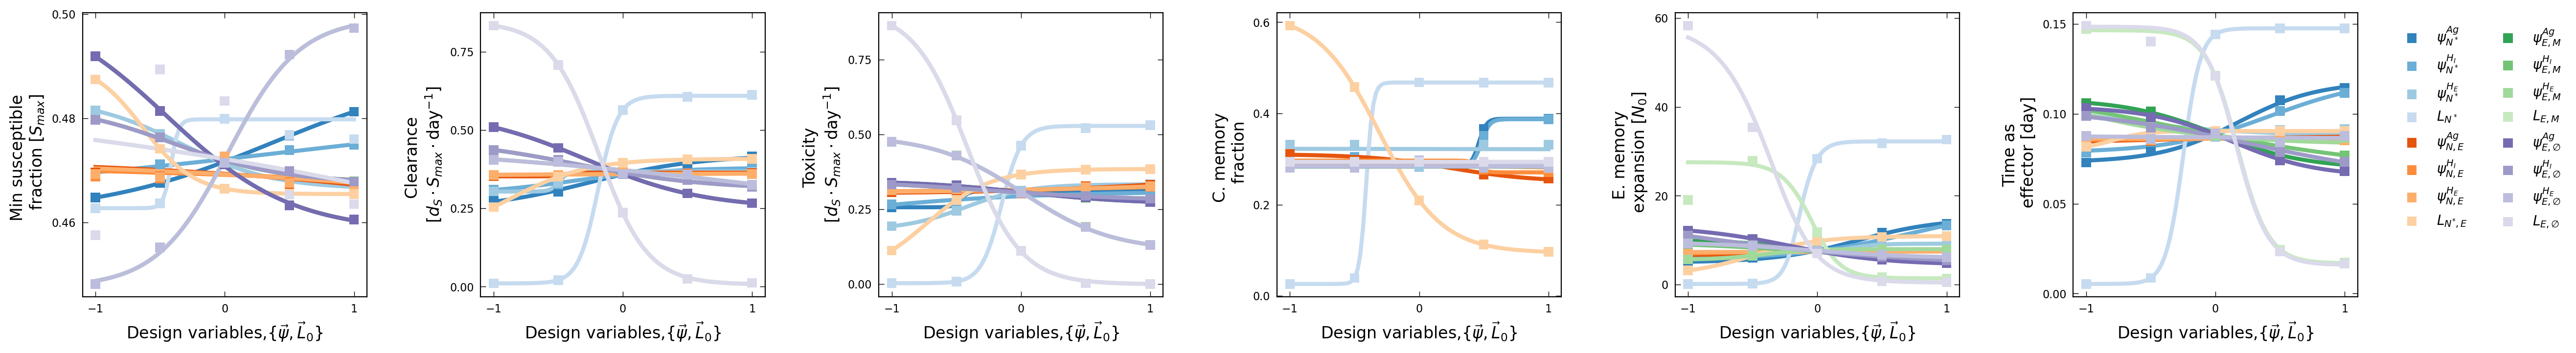

In [6]:
# Fit impact of regulatory parameters on performace: marginalizing over modules
tol = 1e-2

fig, axs = plt.subplots(1, len(perf_vars), 
                              figsize=(len(perf_vars)**2 - len(perf_vars), 4), sharex=True, sharey=False)

for module_index in np.arange(0, len(modules)):
    reg_choice_label = modules[module_index]
    reg_choice = module_reg[reg_choice_label]
    zero_regs = np.concatenate([(module_reg[modules[u]] if u != module_index else []) for u in np.arange(0, len(modules))]).tolist()
    
    x_varname= key_var

    for j, p in enumerate(signal_classes):
        data_mean = clustered_mean_df.groupby(reg_choice[j], as_index = False).mean()
        
        for i, var in enumerate(perf_vars):
            im = axs[i].scatter(data_mean[reg_choice[j]]/np.amax(data_mean[reg_choice[j]]), 
                                (10**data_mean[var] - 1) if i == 4 or i == 5 else data_mean[var], 
                              marker = 's', s = 50, color = cmap_colors[module_index*len(reg_choice) + j], 
                                edgecolors = 'None',label = reg_label[module_index*len(reg_choice) + j ])

            y_max = np.max(data_mean[var].values)
            y_min = np.min(data_mean[var].values)
            y_std = np.std(data_mean[var].values)

            popt, pcov, infodict, _, _ = curve_fit(sigmoid_1d, data_mean[reg_choice[j]].values, data_mean[var].values, 
                                   p0 =(y_max, y_min, 0.0, 0.0),
                                   method = 'trf', 
                                   bounds = ([y_max - tol*y_std, np.minimum(2*y_min, 0), -4*L0_max, -4*L0_max], 
                                             [2*y_max if y_max > 0 else y_std*tol, np.maximum(y_min, 0) + y_std*tol, 4*L0_max, 4*L0_max]),
                                   maxfev=10000,
                                   full_output = True)

            x = np.linspace(-np.max(data_mean[reg_choice[j]]), np.max(data_mean[reg_choice[j]]), 100)
            axs[i].plot(x/np.amax(x), (10**sigmoid_1d(x, *popt) - 1) if i == 4 or i == 5 else sigmoid_1d(x, *popt), 
                        linestyle='-',
                        linewidth = 3.0,
                        color = cmap_colors[module_index*len(reg_choice) + j], 
                        zorder = 0)

            if i == 0:
                print("fevals:", infodict['nfev'])

            if module_index + j == 0: 
                axs[i].minorticks_off()
                axs[i].yaxis.set_tick_params(labelbottom=True)
                axs[i].xaxis.set_tick_params(labelbottom=True)
                axs[i].tick_params(axis='both', which='major', labelsize=8)
                axs[i].set_box_aspect(1)
                axs[i].locator_params(axis='y', nbins=4)
                axs[i].locator_params(axis='x', nbins=4)
                axs[i].set_ylabel(perf_labels[i], fontsize = 12)
                axs[i].set_xlabel(r'Design variables,$\{\vec\psi, \vec L_0 \}$', fontsize = 12)

axs[-1].legend(bbox_to_anchor=(1.1, 1), fontsize=10, framealpha=0, ncol = 2)
fig.subplots_adjust(wspace=.4, hspace=.35)
plt.savefig('_figs/'+comment+'-'+'mean_regulation_trends_by_performance'+'.png', dpi=150, bbox_inches="tight")

In [7]:
del clustered_mean_df

### Fit model to individual infection scenarios and with all regulatory modules as variables

In [9]:
# Regress Performance measures on regulation parameters
num_cpu = 130
variables = reg
tol = 1e-2

def model(input, fit = "non-linear"):

    out = []
    infection = input[vir_vars].values[0]
    runtimes = str(np.round(infection, 3))+': '
    
    for i, perf in enumerate(perf_vars):
        # run regression
        start = time.time() # timestamp start
        
        if fit == "linear":
            input.loc[:,'dep_var'] = np.log(1 + input[perf].values) if 'Memory' in perf_labels[perf_vars.index(perf)] or 'magnitude' in perf_labels[perf_vars.index(perf)] else input[perf].values
            lr = smf.ols('dep_var ~ ' + ' + '.join(variables), data=input).fit()
    
            # save values
            out.append( (lr.params.values[0: 1 + len(variables)]).tolist() + np.sqrt(np.diag(lr.cov_params())).tolist() + infection.tolist() + [np.mean(input[perf].values), i] )
        else:
            y_max = np.max(input[perf].values)
            y_min = np.min(input[perf].values)
            y_std = np.std(input[perf].values)
            popt, pcov = curve_fit(sigmoid, input[variables].values, input[perf].values, 
                           p0 =[y_max, y_min] + len(variables)*[0.0] + num_modules*[0.0],
                           method = 'trf', 
                           bounds = ([y_max - y_std*tol, np.minimum(0.0, y_min)] + len(variables)*[-5.0*L0_max] + num_modules*[-5.0*L0_max], 
                                     [1.0 if perf == "frac_cM" else (y_max + y_std*tol), y_min + y_std*tol] + len(variables)*[5.0*L0_max] + num_modules*[5.0*L0_max]), 
                                   maxfev=100000,
                                   full_output = False)
            
            residuals = input[perf].values - sigmoid(input[variables].values, *popt)
            rmse = np.sqrt(np.mean(residuals**2))
            out.append(popt.tolist() + np.sqrt(np.diag(pcov)).tolist() + infection.tolist() + [np.mean(input[perf].values), 
                                                                                               np.max(input[perf].values), 
                                                                                               np.min(input[perf].values), 
                                                                                               np.median(input[perf].values), 
                                                                                               i, rmse, y_std, 
                                                                                               np.amax(input['scaled_min_pS'].values),
                                                                                               input['harm_pI_noprotection'].values[0],
                                                                                               np.mean(input.loc[np.sum(np.abs(input[reg_stim]), axis = 1) == 0,'stim_pI'].values), 
                                                                                               np.mean(input.loc[np.sum(np.abs(input[reg_stim]), axis = 1) == 0,'stim_pHI'].values),
                                                                                               np.mean(input.loc[np.sum(np.abs(input[reg_stim]), axis = 1) == 0,'stim_pHE'].values)])

            # if i == 0:
            #     print("fevals:", infodict['nfev'])
        end = time.time() # timestamp start
        runtimes += (perf+ ' = ' + str((end - start)/3600)+' hrs, ')
        
    #print(runtimes)
    out_data = pd.DataFrame(np.vstack(out), 
                            columns = ['y_max', 'y_min'] \
                            + variables + [('intercept_' + j) for j in modules] \
                            + ['sigma_y_max', 'sigma_y_min'] + ['sigma_'+r  for r in variables] \
                            + [('sigma_intercept_' + j) for j in modules] \
                            + vir_vars \
                            + ['mean_perf', 'max_perf', 'min_perf', 'median_perf', 'perf_index', 'rmse', 'y_std', 'max_scaled_min_pS', 'harm_pI_noprotection', 'stim_pI', 'stim_pHI', 'stim_pHE'])
    out_data['antigenicity_over_harm'] = antigenicity_over_harm(out_data)
    out_data.to_pickle('/gscratch/scrubbed/oukogu/infoimmune/sim_output/no_cell_var/summary_stats/mean/fits/'+comment+runs+'fit_'+str(np.round(infection, 3))+'.pkl')
    
    return np.vstack(out)

# Compile datasets
impact_data = pd.DataFrame(np.vstack(Parallel(n_jobs = num_cpu, batch_size = max(int(n_virs/num_cpu),1))(delayed(model)(input = data.groupby(vir_vars + variables, as_index=False).mean(), fit = "nonlinear") 
                                                                                                            for data in infection_scenarios)), 
                            columns = ['y_max', 'y_min'] \
                            + variables + [('intercept_' + j) for j in modules] \
                            + ['sigma_y_max', 'sigma_y_min'] + ['sigma_'+r  for r in variables] \
                            + [('sigma_intercept_' + j) for j in modules] \
                            + vir_vars \
                            + ['mean_perf', 'max_perf', 'min_perf', 'median_perf', 'perf_index', 'rmse', 'y_std', 'max_scaled_min_pS', 'harm_pI_noprotection', 'stim_pI', 'stim_pHI', 'stim_pHE'])
impact_data['antigenicity_over_harm'] = antigenicity_over_harm(impact_data)

impact_data.to_pickle('/gscratch/scrubbed/oukogu/infoimmune/sim_output/no_cell_var/summary_stats/mean/'+comment+runs+'impact_data'+'.pkl')

In [10]:
# # IF the above fails: Compile datasets
# num_cpu = 150
# file_list = [f for f in os.listdir(d) if comment in f]
# num_files = len(file_list)

# def import_fits(f,d):
    
#     file_path = os.path.join(d, f)
#     with open(file_path, 'rb') as filename:  
#         out = pickle.load(filename)

#     return out

# impact_data = pd.concat(Parallel(n_jobs = num_cpu, batch_size = max(int(n_virs/num_cpu),1))(delayed(import_fits)(f = file_name, d = d) 
#                                                                                                             for file_name in file_list))
# impact_data['antigenicity_over_harm'] = antigenicity_over_harm(impact_data)

# impact_data.to_pickle('/gscratch/scrubbed/oukogu/infoimmune/sim_output/no_cell_var/summary_stats/mean/'+comment+runs+'impact_data'+'.pkl')

In [22]:
# View result
perf_choice = 1 # chose observable
impact_data = pd.read_pickle('/gscratch/scrubbed/oukogu/infoimmune/sim_output/no_cell_var/summary_stats/mean/'+comment+runs+'impact_data'+'.pkl')
with pd.option_context('display.max_columns', None,'display.max_rows', None):
    display(impact_data.loc[(impact_data.perf_index == perf_choice)])

,y_max,y_min,psi_myc_I,psi_myc_HI,psi_myc_HE,L0_Na,psi_NE_I,psi_NE_HI,psi_NE_HE,L0_NE,psi_EM_I,psi_EM_HI,psi_EM_HE,L0_EM,psi_Edie_I,psi_Edie_HI,psi_Edie_HE,L0_Edie,intercept_Na,intercept_NE,intercept_EM,intercept_EE,sigma_y_max,sigma_y_min,sigma_psi_myc_I,sigma_psi_myc_HI,sigma_psi_myc_HE,sigma_L0_Na,sigma_psi_NE_I,sigma_psi_NE_HI,sigma_psi_NE_HE,sigma_L0_NE,sigma_psi_EM_I,sigma_psi_EM_HI,sigma_psi_EM_HE,sigma_L0_EM,sigma_psi_Edie_I,sigma_psi_Edie_HI,sigma_psi_Edie_HE,sigma_L0_Edie,sigma_intercept_Na,sigma_intercept_NE,sigma_intercept_EM,sigma_intercept_EE,d_I,K_I,b_I,K_H,N_0,S_0,I_0,mean_perf,max_perf,min_perf,median_perf,perf_index,rmse,y_std,max_scaled_min_pS,harm_pI_noprotection,stim_pI,stim_pHI,stim_pHE,antigenicity_over_harm
1,5.525475,1.622574e-02,3.855719,0.046569,0.087588,3.891885,0.311421,-0.016516,-0.002451,1.111483,-8.509384,-0.355279,-0.407227,-4.546062,-8.802096,-0.371623,-0.408009,-4.712230,3.537517,5.362949,-2.362299,-2.378865,0.004453,0.001037,0.032663,0.005494,0.005519,0.033002,0.005804,0.005532,0.005531,0.016010,0.060041,0.008391,0.008652,0.034239,0.064041,0.008690,0.008874,0.037031,0.032793,0.064817,0.011609,0.011790,0.150,1.000000e+04,1.500000e-07,100000.0,100.0,10000000.0,1000.0,0.594919,5.509250,0.0,3.412751e-04,1.0,0.514959,1.622574,0.985673,5.516209,6.030474,1.618029,0.365198,3.349148e+00
7,5.523498,1.602687e-02,7.715928,0.059586,0.090029,9.047650,0.199614,0.004417,-0.006718,0.991381,-4.433979,-0.158663,-0.237414,-4.244029,-4.277397,-0.138719,-0.196120,-4.111178,5.954745,4.864923,-2.238110,-2.229968,0.004859,0.001029,0.609989,0.006874,0.006917,0.686415,0.005485,0.005366,0.005366,0.013822,0.034335,0.005677,0.005797,0.028682,0.031345,0.005568,0.005646,0.026483,0.458209,0.055998,0.010388,0.010301,0.150,1.995262e+04,1.500000e-07,100000.0,100.0,10000000.0,1000.0,0.583863,5.507471,0.0,2.670070e-04,1.0,0.515683,1.602687,0.966492,5.516209,5.380057,1.619471,0.367117,2.576268e+00
13,5.520739,1.585445e-02,3.425881,0.034517,0.183829,7.268171,0.114473,0.015293,-0.000214,1.039683,-4.334052,-0.160887,-0.254217,-4.648447,-4.294052,-0.157165,-0.236157,-4.600388,4.088118,5.001876,-2.405028,-2.403913,0.004343,0.000928,0.048726,0.006190,0.006436,0.107231,0.004825,0.004789,0.004788,0.013278,0.022314,0.005293,0.005525,0.023957,0.021983,0.005244,0.005429,0.023586,0.070286,0.053701,0.010964,0.010953,0.150,3.981072e+04,1.500000e-07,100000.0,100.0,10000000.0,1000.0,0.572420,5.504885,0.0,1.933211e-04,1.0,0.465827,1.585445,0.942342,5.516209,4.735831,1.621817,0.370494,2.093217e+00
19,5.517010,1.528934e-02,2.528087,0.160867,0.620477,6.351326,0.083606,0.023250,0.015351,1.206732,-2.862077,-0.330118,-0.463633,-3.618185,-2.781712,-0.334586,-0.522609,-3.588968,3.344105,5.695833,-2.200479,-2.196024,0.004202,0.000891,0.023468,0.007222,0.009781,0.053967,0.004761,0.004744,0.004743,0.017980,0.014663,0.004753,0.005074,0.018154,0.014364,0.004733,0.005184,0.018099,0.029559,0.072604,0.008653,0.008592,0.150,7.943282e+04,1.500000e-07,100000.0,100.0,10000000.0,1000.0,0.556219,5.501376,0.0,1.333998e-04,1.0,0.446381,1.563401,0.923275,5.516209,4.097782,1.622576,0.367939,1.762709e+00
25,5.512669,1.105824e-02,2.140073,0.242140,1.418574,7.533230,0.071516,0.012339,-0.001940,1.158761,-1.731716,-0.294767,-0.549684,-3.458854,-1.722460,-0.294107,-0.549119,-3.481602,3.255610,5.433469,-2.366948,-2.362283,0.004012,0.000817,0.018556,0.007501,0.013733,0.061136,0.004262,0.004249,0.004249,0.014384,0.008801,0.004206,0.004757,0.015352,0.008771,0.004216,0.004770,0.015465,0.026061,0.058084,0.009009,0.008999,0.150,1.584893e+05,1.500000e-07,100000.0,100.0,10000000.0,1000.0,0.538780,5.497274,0.0,9.151810e-05,1.0,0.410268,1.539531,0.917274,5.516209,3.468986,1.625118,0.367416,1.522340e+00
31,5.503490,4.642052e-03,1.680648,0.501599,2.542361,9.376118,0.045170,0.030793,0.003420,1.204202,-1.197815,-0.284888,-0.543115,-3.134707,-1.192869,-0.286288,-0.531306,-3.107393,3.688185,5.488060,-2.463815,-2.462323,0.003926,0.000750,0.017536,0.008934,0.024666,0.088447,0.003776,0.003774,0.00

#### Check the model goodness of the fit
The model does a pretty good job as the $R^2$ values for clearance, toxicity and memory are above 0.80.

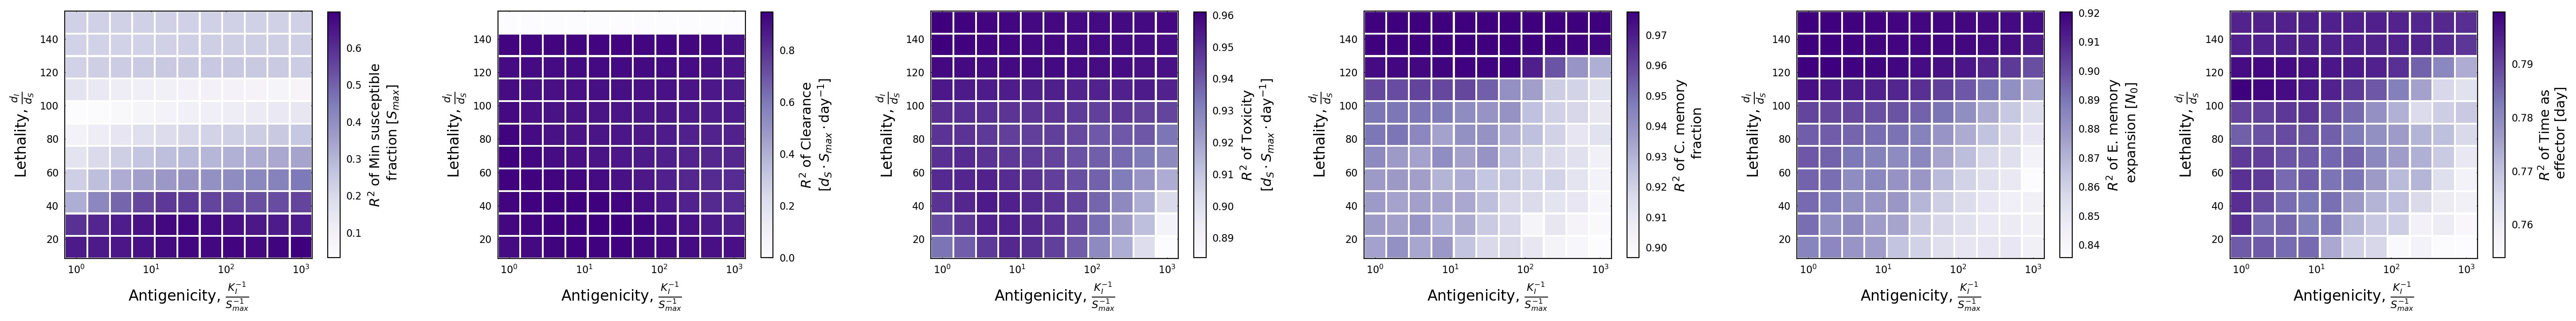

In [12]:
# Examine goodness of fit through R-squared
plots = [vir_vars[1], vir_vars[0]]
plot_labels = ["Antigenicity, "+r"$\frac{K_{I}^{-1}}{S_{max}^{-1}}$", "Lethality, "+r"$\frac{d_{I}}{d_{S}}$"]
size = 3200/np.sqrt(len(infection_scenarios))

fig, axs = plt.subplots(1, len(perf_vars), 
                          figsize=(len(perf_vars)**2, 2*len(perf_vars)), sharex='row', sharey='col')

x_varname, y_varname = plots[0], plots[1]
for i, perf in enumerate(perf_vars):
    data = impact_data[(impact_data.perf_index == i)*(impact_data.I_0 <= I_min)]
    model_r_sq = (1 - data.rmse**2/data.y_std**2)*(data.y_std > tol)
    z_label = r"$R^2$ of "+perf_labels[i]
    
    im = axs[i].scatter(data['S_0']/data[x_varname] if x_varname == 'K_I' else data[x_varname]/d_S,
                                 data['S_0']/data[y_varname] if y_varname == 'K_I' else data[y_varname]/d_S,
                      marker ='s', s = size, c = model_r_sq, cmap='Purples', edgecolors = 'None',# alpha = 0.8, 
                      norm = mpl.colors.Normalize())

    if x_varname == 'K_I':
        axs[i].semilogx()
    if y_varname == 'K_I':
        axs[i].semilogy()
        
    axs[i].minorticks_off()
    axs[i].set_box_aspect(1)
    axs[i].tick_params(axis='both', which='major', labelsize=8)

    cb = fig.colorbar(im, ax=axs[i], orientation='vertical', shrink = 0.30, pad = 0.05)
    cb.set_label(z_label, fontsize = 11)
    cb.ax.tick_params(labelsize=8)
    
fig.subplots_adjust(wspace=0.40, hspace=0.25)

for k, ax in enumerate(axs.flat):
    ax.set_xlabel(plot_labels[0], fontsize = 12)
    ax.set_ylabel(plot_labels[1], fontsize = 12)

plt.savefig('_figs/'+comment+'-fits-r-squared'+'.png', dpi=150, bbox_inches="tight")

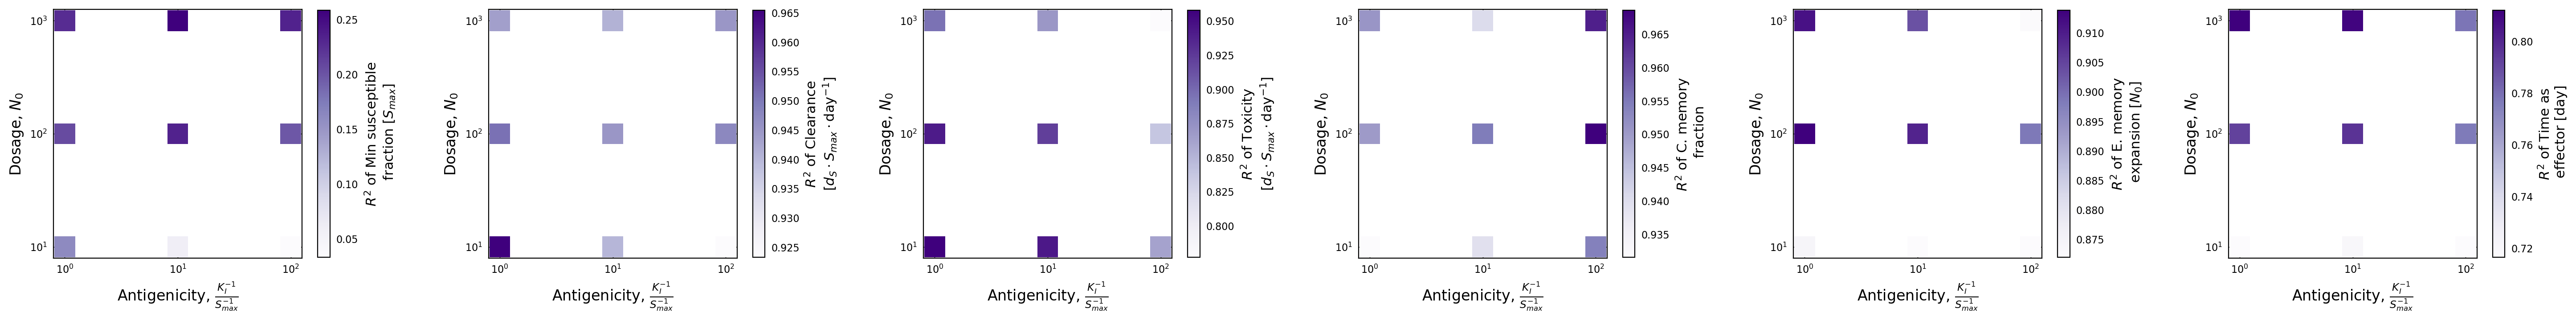

In [13]:
# Examine goodness of fit through R-squared
size = 3200/np.sqrt(len(infection_scenarios))

fig, axs = plt.subplots(1, len(perf_vars), 
                          figsize=(len(perf_vars)**2, 2*len(perf_vars)), sharex='row', sharey='col')

x_varname, y_varname = vir_vars[1], vir_vars[4]
for i, perf in enumerate(perf_vars):
    data = impact_data[(impact_data.perf_index == i)*(impact_data.I_0 > I_min)]
    model_r_sq = (1 - data.rmse**2/data.y_std**2) #*(data.y_std > tol)
    z_label = r"$R^2$ of "+perf_labels[i]
    
    im = axs[i].scatter(data['S_0']/data[x_varname], data[y_varname],
                      marker ='s', s = size, c = model_r_sq, cmap='Purples', edgecolors = 'None',# alpha = 0.8, 
                      norm = mpl.colors.Normalize())

    axs[i].semilogx()
    axs[i].semilogy()
        
    axs[i].minorticks_off()
    axs[i].set_box_aspect(1)
    axs[i].tick_params(axis='both', which='major', labelsize=8)

    cb = fig.colorbar(im, ax=axs[i], orientation='vertical', shrink = 0.30, pad = 0.05)
    cb.set_label(z_label, fontsize = 11)
    cb.ax.tick_params(labelsize=8)
    
fig.subplots_adjust(wspace=0.40, hspace=0.25)

for k, ax in enumerate(axs.flat):
    ax.set_xlabel("Antigenicity, "+r"$\frac{K_{I}^{-1}}{S_{max}^{-1}}$", fontsize = 12)
    ax.set_ylabel("Dosage, "+r"$N_0$", fontsize = 12)

plt.savefig('_figs/'+comment+'-fits-r-squared-cancers'+'.png', dpi=150, bbox_inches="tight")

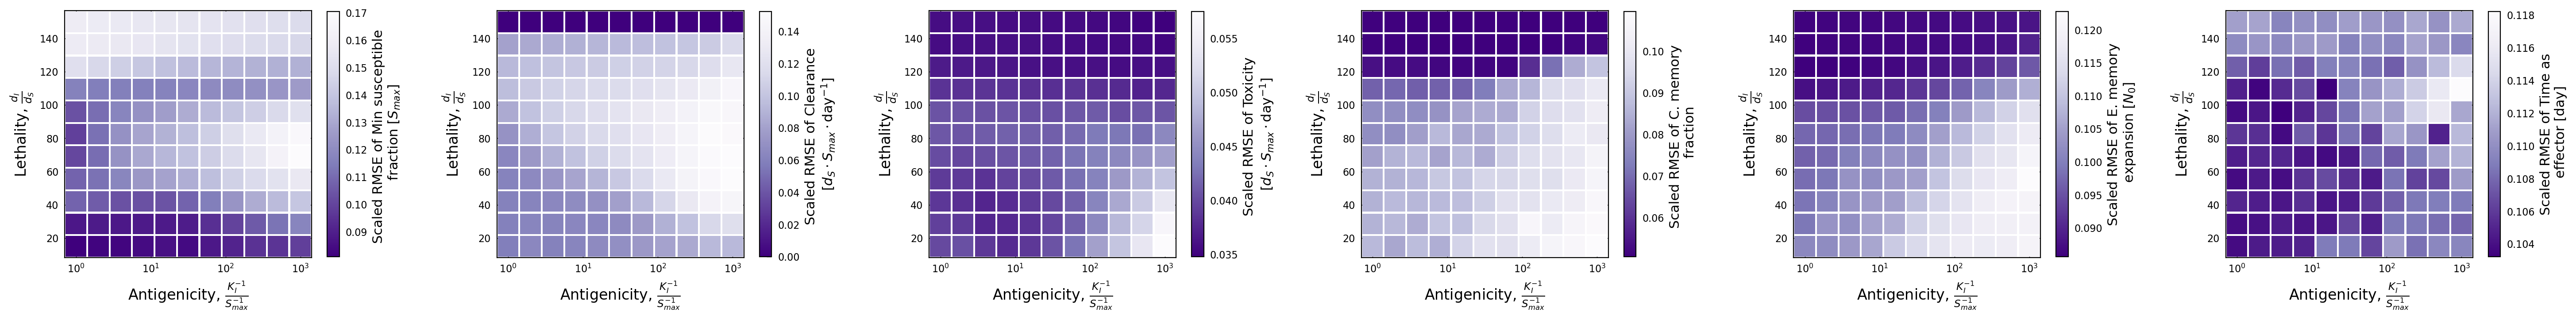

In [14]:
# Examine goodness of fit through scaled-RMSE
fig, axs = plt.subplots(1, len(perf_vars), 
                          figsize=(len(perf_vars)**2, 2*len(perf_vars)), sharex='row', sharey='col')

x_varname, y_varname = plots[0], plots[1]
for i, perf in enumerate(perf_vars):
    data = impact_data[(impact_data.perf_index == i)*(impact_data.I_0 <= I_min)]
    model_rmse_over_max = (data.rmse/data.y_max)*(data.y_std > tol)
    z_label = "Scaled RMSE of "+perf_labels[i]
    
    im = axs[i].scatter(data['S_0']/data[x_varname] if x_varname == 'K_I' else data[x_varname]/d_S,
                                 data['S_0']/data[y_varname] if y_varname == 'K_I' else data[y_varname]/d_S,
                      marker ='s', s = size, 
                        c = model_rmse_over_max, cmap='Purples_r', edgecolors = 'None',# alpha = 0.8, 
                      norm = mpl.colors.Normalize())

    if x_varname == 'K_I':
        axs[i].semilogx()
    if y_varname == 'K_I':
        axs[i].semilogy()
        
    axs[i].minorticks_off()
    axs[i].set_box_aspect(1)
    axs[i].tick_params(axis='both', which='major', labelsize=8)

    cb = fig.colorbar(im, ax=axs[i], orientation='vertical', shrink = 0.30, pad = 0.05)
    cb.set_label(z_label, fontsize = 11)
    cb.ax.tick_params(labelsize=8)
    
fig.subplots_adjust(wspace=0.40, hspace=0.25)

for k, ax in enumerate(axs.flat):
    ax.set_xlabel(plot_labels[0], fontsize = 12)
    ax.set_ylabel(plot_labels[1], fontsize = 12)

plt.savefig('_figs/'+comment+'-fits-scaled-rmse'+'.png', dpi=150, bbox_inches="tight")

Effector memory expansion appears challenging to fit based on the $R^2$ values. Looks much better when we look at scaled RMSE. Rationalize by observing tha effector memory expansion has non-monotonic dependence on some variables which can lead to a low variance estimate, and make the $R^2$ values look bad.

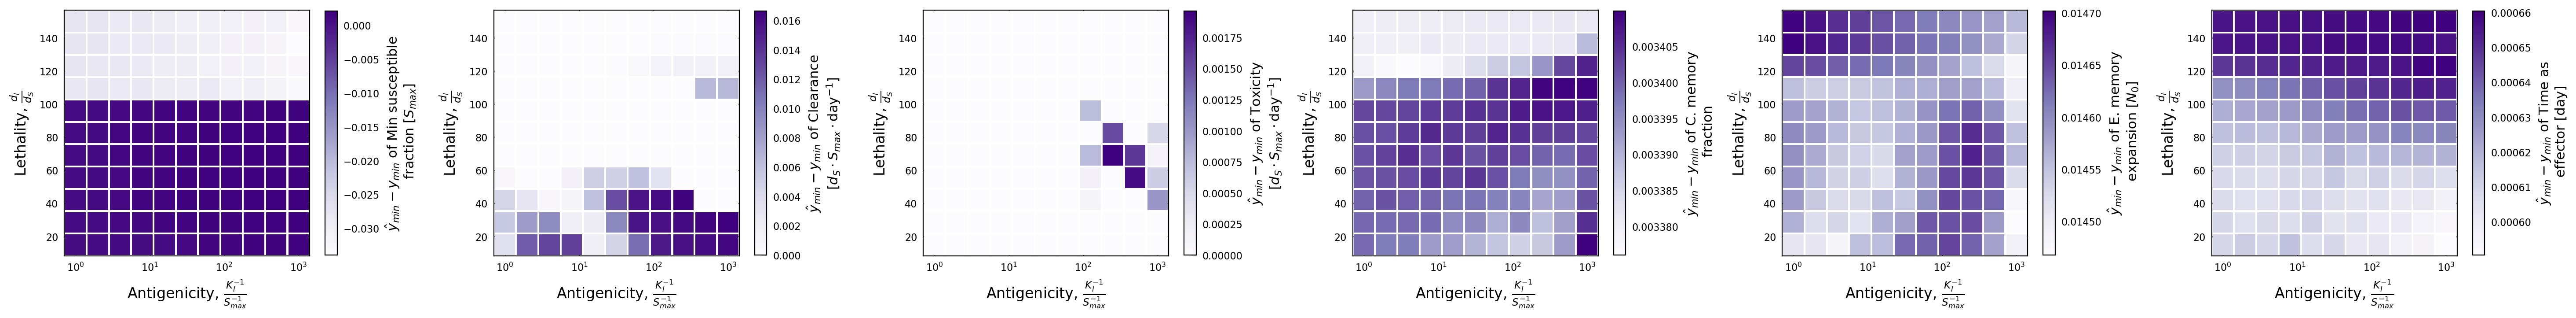

In [15]:
# Examine difference between observed and predicted minima
fig, axs = plt.subplots(1, len(perf_vars), 
                          figsize=(len(perf_vars)**2, 2*len(perf_vars)), sharex='row', sharey='col')

x_varname, y_varname = plots[0], plots[1]
for i, perf in enumerate(perf_vars):
    data = impact_data[(impact_data.perf_index == i)*(impact_data.I_0 <= I_min)]
    z_label = r"$\hat{y}_{min} - y_{min}$ of "+perf_labels[i]
    
    im = axs[i].scatter(data['S_0']/data[x_varname] if x_varname == 'K_I' else data[x_varname]/d_S,
                                 data['S_0']/data[y_varname] if y_varname == 'K_I' else data[y_varname]/d_S,
                      marker ='s', s = size, c = (data.y_min - data.min_perf)*(data.y_std > tol), cmap='Purples', edgecolors = 'None',# alpha = 0.8, 
                      norm = mpl.colors.Normalize())

    if x_varname == 'K_I':
        axs[i].semilogx()
    if y_varname == 'K_I':
        axs[i].semilogy()
        
    axs[i].minorticks_off()
    axs[i].set_box_aspect(1)
    axs[i].tick_params(axis='both', which='major', labelsize=8)

    cb = fig.colorbar(im, ax=axs[i], orientation='vertical', shrink = 0.30, pad = 0.05)
    cb.set_label(z_label, fontsize = 11)
    cb.ax.tick_params(labelsize=8)
    
fig.subplots_adjust(wspace=0.40, hspace=0.25)

for k, ax in enumerate(axs.flat):
    ax.set_xlabel(plot_labels[0], fontsize = 12)
    ax.set_ylabel(plot_labels[1], fontsize = 12)

plt.savefig('_figs/'+comment+'-fits-y_min'+'.png', dpi=150, bbox_inches="tight")

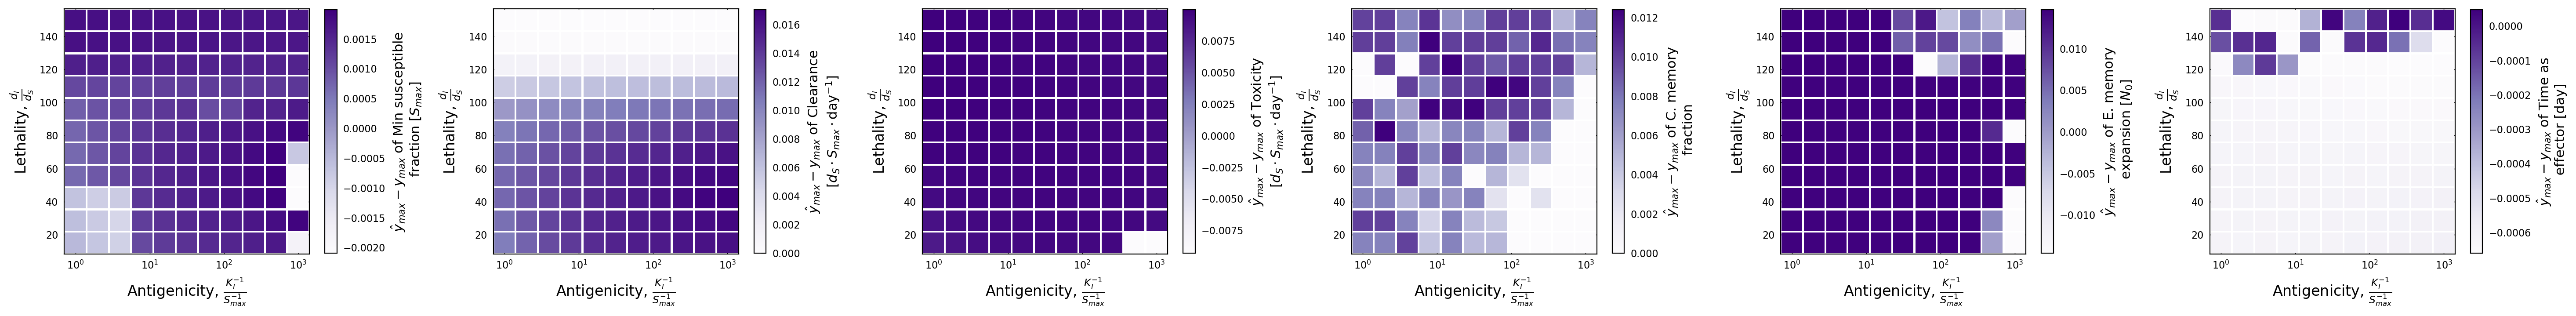

In [16]:
# Examine difference between observed and predicted maxima
plots = [vir_vars[1], vir_vars[0]]

fig, axs = plt.subplots(1, len(perf_vars), 
                          figsize=(len(perf_vars)**2, 2*len(perf_vars)), sharex='row', sharey='col')

x_varname, y_varname = plots[0], plots[1]
for i, perf in enumerate(perf_vars):
    data = impact_data[(impact_data.perf_index == i)*(impact_data.I_0 <= I_min)]
    z_label = r"$\hat{y}_{max} - y_{max}$ of "+perf_labels[i]
    
    im = axs[i].scatter(data['S_0']/data[x_varname] if x_varname == 'K_I' else data[x_varname]/d_S,
                                 data['S_0']/data[y_varname] if y_varname == 'K_I' else data[y_varname]/d_S,
                      marker ='s', s = size, c = (data.y_max - data.max_perf)*(data.y_std > tol), cmap='Purples', edgecolors = 'None',# alpha = 0.8, 
                      norm = mpl.colors.Normalize())

    if x_varname == 'K_I':
        axs[i].semilogx()
    if y_varname == 'K_I':
        axs[i].semilogy()
        
    axs[i].minorticks_off()
    axs[i].set_box_aspect(1)
    axs[i].tick_params(axis='both', which='major', labelsize=8)

    cb = fig.colorbar(im, ax=axs[i], orientation='vertical', shrink = 0.30, pad = 0.05)
    cb.set_label(z_label, fontsize = 11)
    cb.ax.tick_params(labelsize=8)
    
fig.subplots_adjust(wspace=0.40, hspace=0.25)

for k, ax in enumerate(axs.flat):
    ax.set_xlabel(plot_labels[0], fontsize = 12)
    ax.set_ylabel(plot_labels[1], fontsize = 12)

plt.savefig('_figs/'+comment+'-fits-y_max'+'.png', dpi=150, bbox_inches="tight")

The distribution of the values of the bias parameters gives us a sense of how well our simulations can explain variation due to that module. In this case the Naive to Memory module has a computed bias for clearance/toxicity that is at the maximum allowable. However the value is less extreme for memory formation. This suggests a strong bias towards high clearance/toxicity in this module.

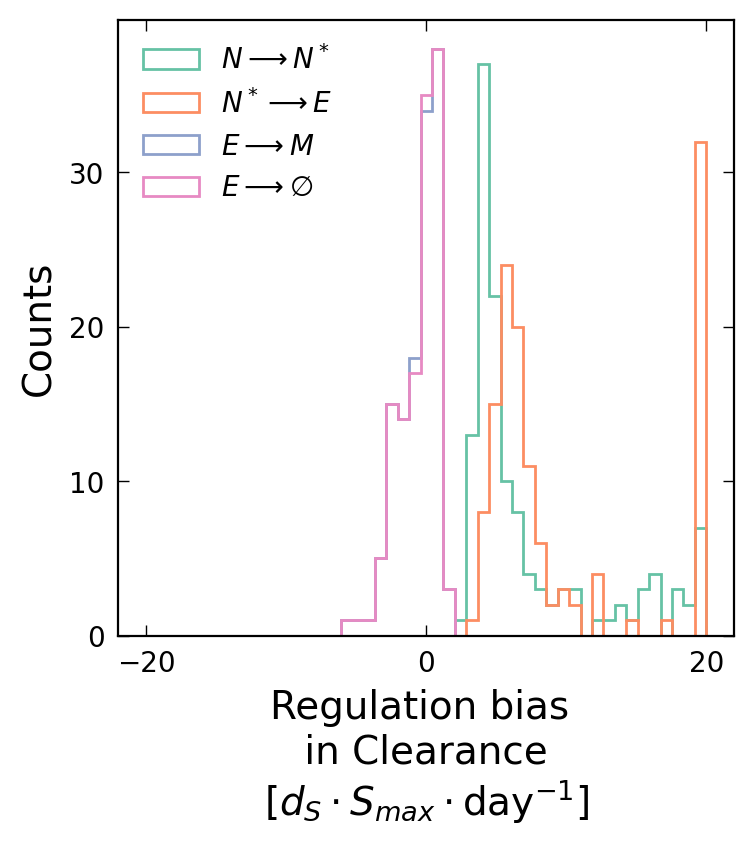

In [23]:
fig, axs = plt.subplots(figsize=(4,4), sharex=False, sharey=False)

cmap_colors = ['#66c2a5', '#fc8d62', '#8da0cb', '#e78ac3']
for i, r in enumerate(modules):
    data = impact_data[(impact_data.perf_index == perf_choice)*(impact_data['K_H'] == K_H)]['intercept_'+r].values
    axs.hist(data, bins = np.linspace(-5*L0_max, 5*L0_max, 50), histtype = 'step', label = module_labels[i], color = cmap_colors[i], stacked = True);

axs.legend(fontsize = 10, ncol = 1)

axs.set_xlabel("Regulation bias \n in "+perf_labels[perf_choice], fontsize = 14)
axs.set_ylabel("Counts", fontsize = 14)
axs.set_box_aspect(1)
axs.minorticks_off()
axs.locator_params(axis='y', nbins=4)
axs.locator_params(axis='x', nbins=4)

#plt.savefig('_figs/'+comment+'-optimal-reg-average_utility'+'.png', dpi=150, bbox_inches="tight")

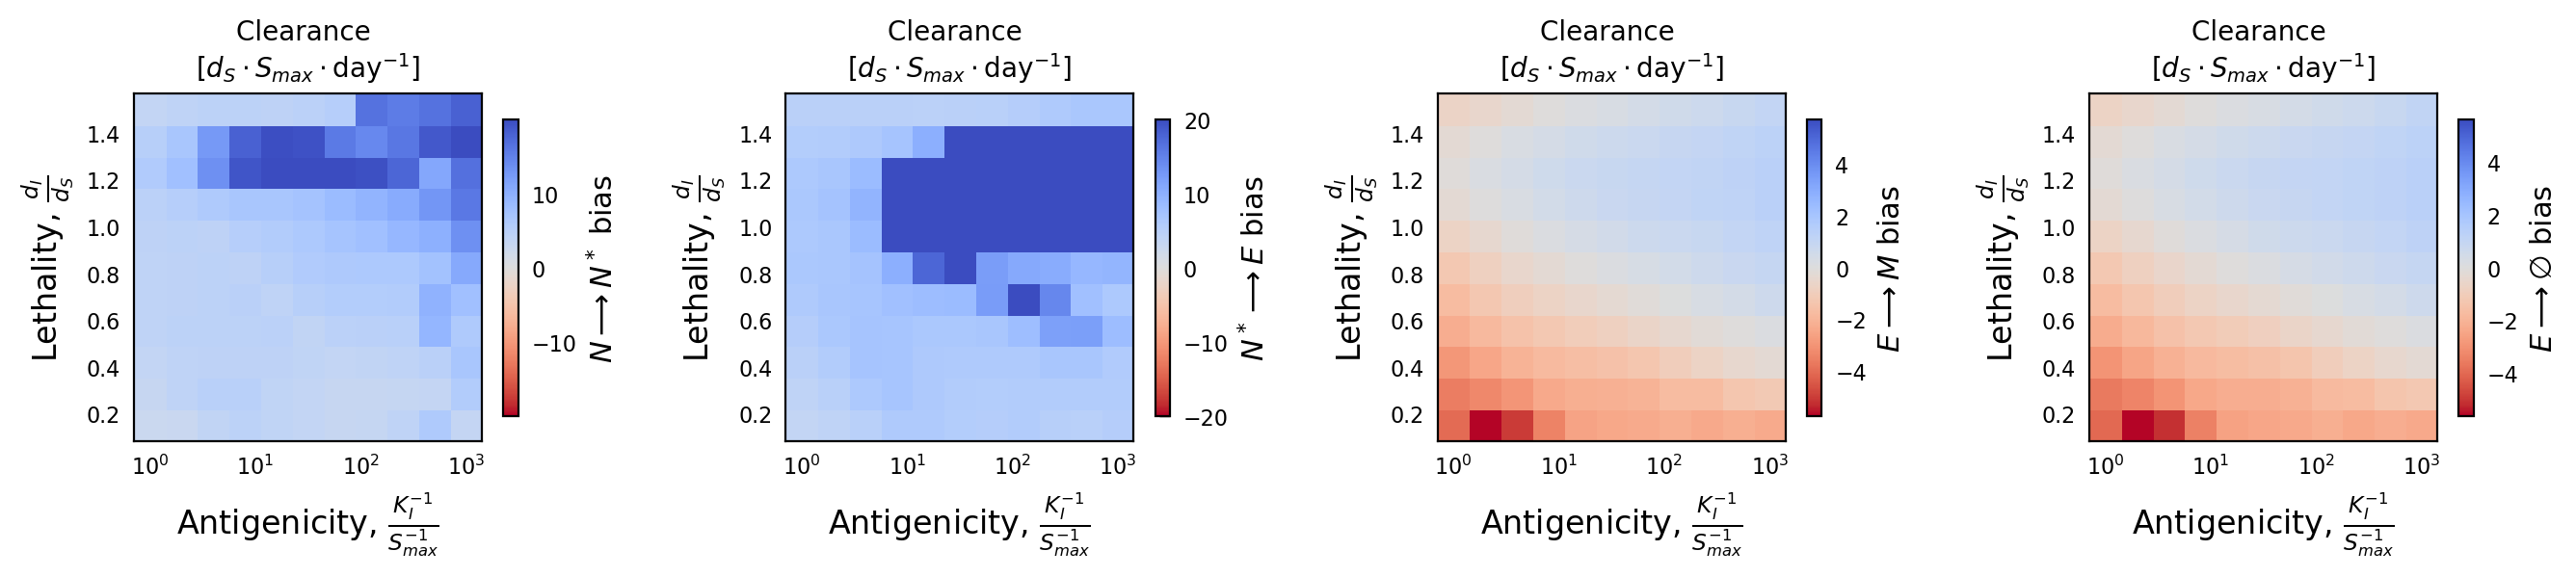

In [18]:
# Visualize optimal regulation
plots = [vir_vars[1], vir_vars[0]]
size = 1750/np.sqrt(len(infection_scenarios))

data = impact_data[(impact_data.perf_index == perf_choice)*(impact_data.I_0 <= I_min)]

fig_c, axs = plt.subplots(1, len(modules), 
                          figsize=(len(modules)**2, 2*len(modules)), sharex='row', sharey='col')

x_varname, y_varname = plots[0], plots[1]
for i, r in enumerate(modules):
    z_varname = 'intercept_'+r
    z_label = module_labels[i]+" bias"
    z = data[z_varname]
    range = np.amax(np.abs(z))
    
    im = axs[i].scatter(S_0/data[x_varname] if x_varname == 'K_I' else data[x_varname],
                                 1/data[y_varname] if y_varname == 'K_I' else data[y_varname],
                      marker ='s', s = size, c = z, cmap='coolwarm_r', edgecolors = 'None',# alpha = 0.8, 
                      norm = mpl.colors.Normalize(vmin = -range, vmax = range))

    if x_varname == 'K_I':
        axs[i].semilogx()
    if y_varname == 'K_I':
        axs[i].semilogy()
        
    axs[i].minorticks_off()
    axs[i].set_box_aspect(1)
    axs[i].tick_params(axis='both', which='major', labelsize=8)
    axs[i].set_title(perf_labels[perf_choice], fontsize = 10.0)

    cb = fig_c.colorbar(im, ax=axs[i], orientation='vertical', shrink = 0.25, pad = 0.05)
    cb.set_label(z_label, fontsize = 11)
    cb.ax.tick_params(labelsize=8)
    
fig_c.subplots_adjust(wspace=.5, hspace=0.25)

for k, ax in enumerate(axs.flat):
    ax.set_xlabel(plot_labels[0], fontsize = 12)
    ax.set_ylabel(plot_labels[1], fontsize = 12)

# plt.savefig('_figs/'+comment+'-optimal-reg-average_prot_tox_hmap'+'.png', dpi=150, bbox_inches="tight")

These intercept values are important because they tell you what the value of the observable would be if we ran our processes, without regulation, at half their maximal characteristic rates. A positive value means that the half-max rate leads to above-median performance/cost. It would be useful to convert these to rates.

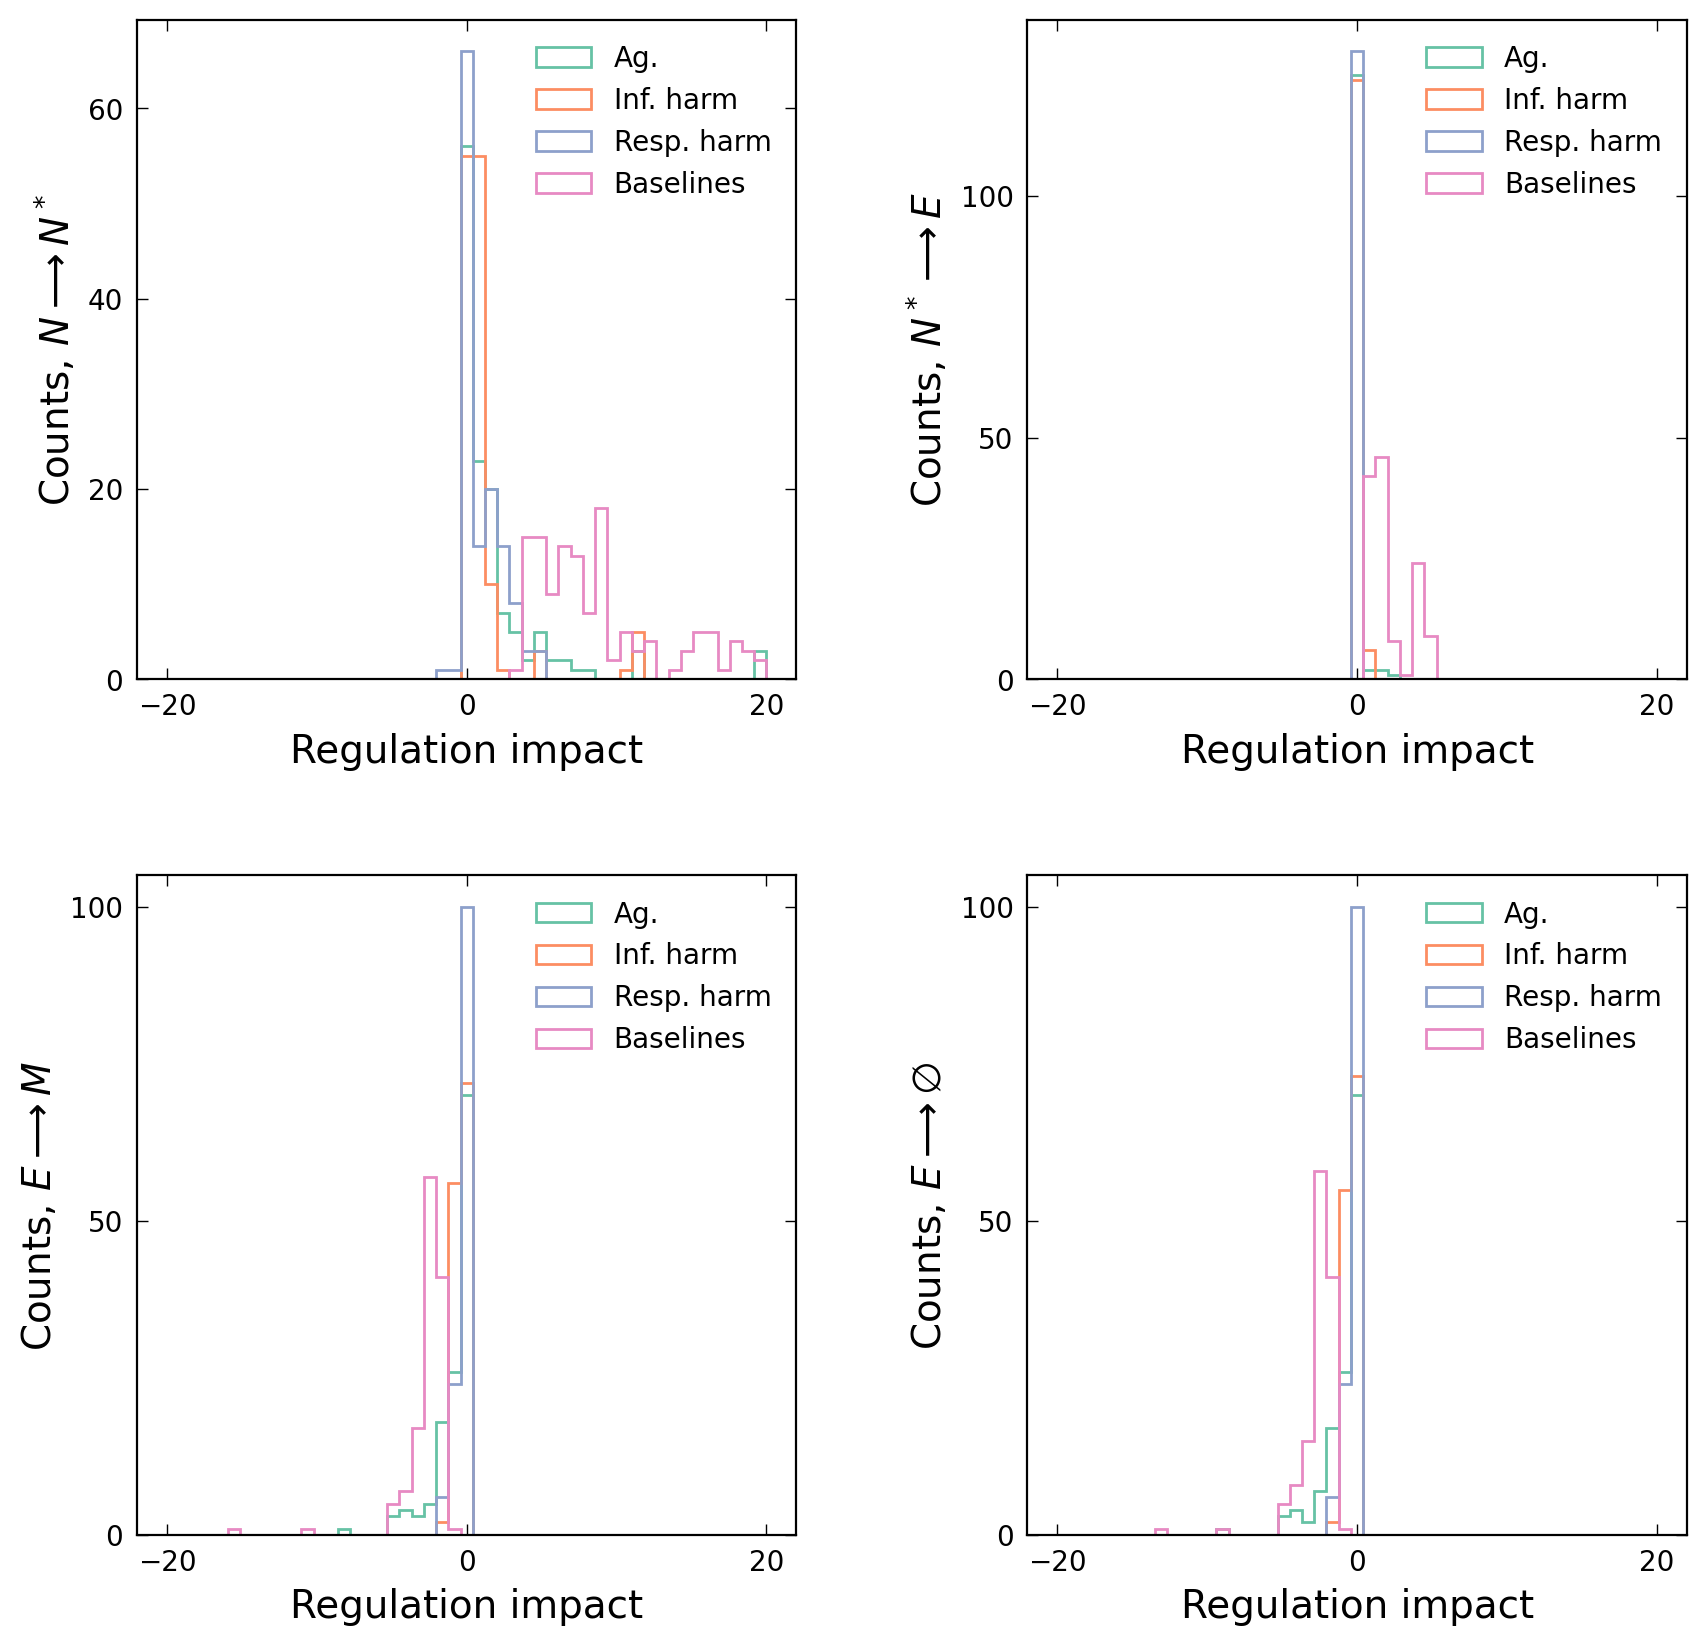

In [19]:
fig, axs = plt.subplots(2,2, figsize=(10,10), sharex=False, sharey=False)

for i, r in enumerate(reg):
    data = impact_data[(impact_data.perf_index == perf_choice)*(impact_data['K_H'] == K_H)][r].values
    module = i // num_modules
    cmap_colors = ['#66c2a5', '#fc8d62', '#8da0cb', '#e78ac3']
    
    x, y = module // 2, module % 2
    axs[x,y].hist(data, bins = np.linspace(-5.0*L0_max, 5.0*L0_max, 50), histtype = 'step', label = signal_classes[i % num_modules], color = cmap_colors[i % num_modules], stacked = True);

    if (i % num_modules) == num_modules -1:
        axs[x,y].legend(fontsize = 10, ncol = 1)
    
        axs[x,y].set_xlabel("Regulation impact", fontsize = 14)
        axs[x,y].set_ylabel("Counts, "+module_labels[i // num_modules], fontsize = 14)
        axs[x,y].set_box_aspect(1)
        axs[x,y].minorticks_off()
        axs[x,y].locator_params(axis='y', nbins=4)
        axs[x,y].locator_params(axis='x', nbins=4)

fig.subplots_adjust(wspace=.35, hspace=.25)

#plt.savefig('_figs/'+comment+'-optimal-reg-average_utility'+'.png', dpi=150, bbox_inches="tight")

In [20]:
with pd.option_context('display.max_columns', None):
    display(impact_data.loc[(impact_data.perf_index == perf_choice)*(impact_data.b_I == 0.0)])

,y_max,y_min,psi_myc_I,psi_myc_HI,psi_myc_HE,L0_Na,psi_NE_I,psi_NE_HI,psi_NE_HE,L0_NE,psi_EM_I,psi_EM_HI,psi_EM_HE,L0_EM,psi_Edie_I,psi_Edie_HI,psi_Edie_HE,L0_Edie,intercept_Na,intercept_NE,intercept_EM,intercept_EE,sigma_y_max,sigma_y_min,sigma_psi_myc_I,sigma_psi_myc_HI,sigma_psi_myc_HE,sigma_L0_Na,sigma_psi_NE_I,sigma_psi_NE_HI,sigma_psi_NE_HE,sigma_L0_NE,sigma_psi_EM_I,sigma_psi_EM_HI,sigma_psi_EM_HE,sigma_L0_EM,sigma_psi_Edie_I,sigma_psi_Edie_HI,sigma_psi_Edie_HE,sigma_L0_Edie,sigma_intercept_Na,sigma_intercept_NE,sigma_intercept_EM,sigma_intercept_EE,d_I,K_I,b_I,K_H,N_0,S_0,I_0,mean_perf,max_perf,min_perf,median_perf,perf_index,rmse,y_std,max_scaled_min_pS,harm_pI_noprotection,stim_pI,stim_pHI,stim_pHE,antigenicity_over_harm


In [21]:
with pd.option_context('display.max_columns', None):
    display(impact_data.loc[(impact_data.perf_index == perf_choice)*(impact_data.b_I == b_C)])

,y_max,y_min,psi_myc_I,psi_myc_HI,psi_myc_HE,L0_Na,psi_NE_I,psi_NE_HI,psi_NE_HE,L0_NE,psi_EM_I,psi_EM_HI,psi_EM_HE,L0_EM,psi_Edie_I,psi_Edie_HI,psi_Edie_HE,L0_Edie,intercept_Na,intercept_NE,intercept_EM,intercept_EE,sigma_y_max,sigma_y_min,sigma_psi_myc_I,sigma_psi_myc_HI,sigma_psi_myc_HE,sigma_L0_Na,sigma_psi_NE_I,sigma_psi_NE_HI,sigma_psi_NE_HE,sigma_L0_NE,sigma_psi_EM_I,sigma_psi_EM_HI,sigma_psi_EM_HE,sigma_L0_EM,sigma_psi_Edie_I,sigma_psi_Edie_HI,sigma_psi_Edie_HE,sigma_L0_Edie,sigma_intercept_Na,sigma_intercept_NE,sigma_intercept_EM,sigma_intercept_EE,d_I,K_I,b_I,K_H,N_0,S_0,I_0,mean_perf,max_perf,min_perf,median_perf,perf_index,rmse,y_std,max_scaled_min_pS,harm_pI_noprotection,stim_pI,stim_pHI,stim_pHE,antigenicity_over_harm
727,0.716040,4.803708e-20,20.000000,5.259423,1.068697,8.724198,2.352988,0.649833,-0.018161,0.964906,-3.436960,-0.957705,-0.217245,-1.503997,-3.461975,-0.957805,-0.213659,-1.508483,4.543300,4.142039,-0.688215,-0.686066,0.000655,0.000106,0.305055,0.081115,0.019606,0.133688,0.013275,0.005600,0.004352,0.005683,0.012743,0.004977,0.003581,0.005383,0.012896,0.005000,0.003595,0.005426,0.071226,0.022797,0.003448,0.003450,0.01,100000.0,0.1,100000.0,10.0,10000000.0,1000000.0,0.071578,0.714180,0.0,0.000005,1.0,0.051510,0.185947,0.947474,1.412133,2.397895,0.680160,0.202349,-7.000001e+00
733,0.740023,3.889929e-19,20.000000,5.257013,1.067358,8.747994,1.806844,0.489408,0.006480,0.749694,-4.078160,-1.123397,-0.239960,-1.779029,-4.080418,-1.124676,-0.243085,-1.780014,4.530792,4.517341,-0.024693,-0.022400,0.000482,0.000106,0.241841,0.064292,0.015490,0.106288,0.009226,0.004264,0.003427,0.004967,0.017844,0.005834,0.003370,0.007851,0.017865,0.005843,0.003376,0.007861,0.056378,0.022059,0.002746,0.002747,0.01,100000.0,0.1,100000.0,100.0,10000000.0,1000000.0,0.095087,0.737829,0.0,0.000127,1.0,0.050216,0.219459,0.949886,1.412133,2.397895,0.680043,0.297640,-7.000001e+00
739,0.768060,9.255437e-04,20.000000,5.262788,1.044525,8.764036,1.305135,0.373644,-0.010642,0.583833,-4.775564,-1.282109,-0.376799,-2.111122,-4.773158,-1.282459,-0.377922,-2.111491,4.622440,4.223086,0.534840,0.534495,0.000491,0.000123,0.253461,0.067384,0.015812,0.111628,0.006856,0.003941,0.003404,0.004394,0.023296,0.007238,0.004107,0.010467,0.023288,0.007240,0.004108,0.010471,0.060408,0.021334,0.003208,0.003208,0.01,100000.0,0.1,100000.0,1000.0,10000000.0,1000000.0,0.117184,0.765581,0.0,0.001488,1.0,0.058087,0.247847,0.955296,1.412133,2.397895,0.679304,0.466102,-7.000001e+00
745,0.707826,5.595620e-34,11.657033,11.601081,1.533586,18.057026,0.700151,0.675747,0.010769,1.043934,-1.087899,-1.051622,-0.284125,-1.703927,-1.094155,-1.049204,-0.283480,-1.706011,4.238149,4.090693,-1.163085,-1.159921,0.000580,0.000086,11.036589,11.036584,0.020346,16.554941,0.004426,0.004364,0.003347,0.004630,0.003793,0.003719,0.002548,0.004557,0.003814,0.003722,0.002550,0.004575,0.052406,0.018135,0.003405,0.003402,0.01,1000000.0,0.1,100000.0,10.0,10000000.0,1000000.0,0.063798,0.706098,0.0,0.000006,1.0,0.042266,0.172765,0.920611,1.412133,0.693147,0.680157,0.170796,-1.451789e+17
751,0.734543,3.427716e-38,11.763955,11.716855,1.585787,18.307223,0.523506,0.496257,0.012899,0.783796,-1.172737,-1.136838,-0.268873,-1.817383,-1.172964,-1.137651,-0.270267,-1.819166,4.362148,4.530317,-0.283458,-0.280966,0.000540,0.000105,8.070472,8.070466,0.020690,12.105798,0.004690,0.004636,0.003939,0.007290,0.005336,0.005217,0.002718,0.007308,0.005344,0.005227,0.002723,0.007327,0.053437,0.030626,0.002690,0.002690,0.01,1000000.0,0.1,100000.0,100.0,10000000.0,1000000.0,0.091693,0.732410,0.0,0.000110,1.0,0.049975,0.213283,0.923699,1.412133,0.693147,0.680024,0.289864,-1.451789e+17
757,0.766868,7.368453e-35,11.350828,11.309650,1.565779,17.760937,0.338620,0.310761,0.002692,0.664875,-1.338839,-1.309370,-0.363319,-2.127086,-1.337141,-1.309012,-0.363225,-2.125603,4.432855,4.419872,0.287822,0.286813,0.000569,0.000125,3.945284,3.945274,0.021964,5.918157,0.005332,0.005288,0.004883,0.009870,0.007069,0.006945,0.003388,0.010230,0.